# ⚙️ 11-04 · 时序特征工程与机器学习

> 目标：把时间序列预测变成**监督学习**。手写**滞后/滚动统计/时间编码**特征构建、
> **ExpandingWindow 时序交叉验证**，用 sklearn 模型做出比「昨值重复」更准的预测。

> 🧩 **生活化类比**：预测明天的销量 = 给模型一堆「小抄」：昨天销量（滞后）、近 7 天均值（滚动）、
> 星期几（时间编码）、最近有没有促销（外生）。机器学习模型的活就是把小抄变成预测。


## 1. 从统计模型到 ML 视角

**核心转变**：ARIMA/指数平滑 =「人工定结构」；ML =「特征 + 模型自动学」。

**特征体系**
| 类别 | 例子 |
|------|------|
| 滞后特征 | $y_{t-1}, y_{t-2}, \\dots$（对应 AR 思想） |
| 滚动统计 | 均值、标准差、最大值、斜率（窗口 7/30） |
| 时间编码 | 星期几、月份、小时、是否节假日（one-hot / 周期编码） |
| 外生变量 | 天气、价格、促销、宏观指标 |
| 差分/比例 | $y_t - y_{t-1}$（增长率） |


Ridge    MAE=0.002 | 昨值重复 MAE=1.650
特征数: 7 （滞后3 + 滚动均值/标准差 + 一阶差分）


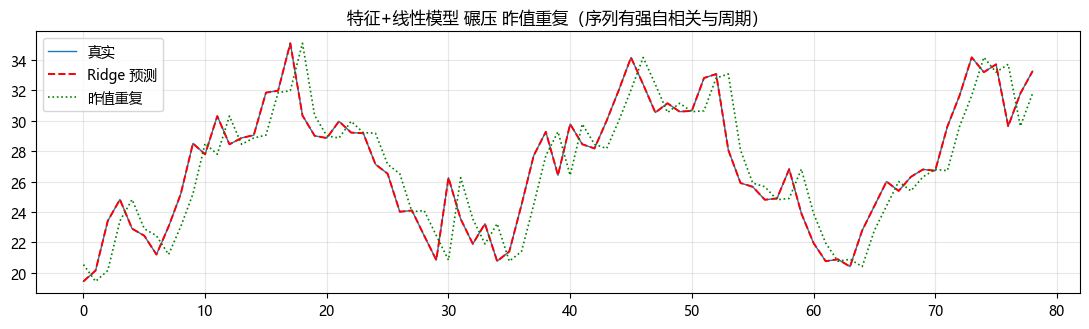

要点：滞后 + 滚动统计已抓住 AR 和季节信息；非线性关系再交给树模型/深度学习


In [1]:
# ---------- 实验 1：手写滑窗特征 + Ridge 预测 vs 昨值重复 ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(0)

n = 400
t = np.arange(n)
y = 20 + 0.02 * t + 5 * np.sin(2 * np.pi * t / 30) + 2 * np.sin(2 * np.pi * t / 7) + rng.normal(0, 1.2, n)

def build_features(series, lags=(1, 2, 3, 7), win=7):
    X, idx = [], []
    start = max(max(lags), win) + 1
    for i in range(start, len(series)):
        row = [series[i - k] for k in lags]
        row += [series[i - win:i].mean(), series[i - win:i].std(), series[i] - series[i - 1]]
        X.append(row); idx.append(i)
    return np.array(X), np.array(idx)

X, idx = build_features(y)
Y = y[idx]                              # 目标 = 当前值（用过去特征预测当前）

split = int(0.8 * len(X))
Xtr, Xte, Ytr, Yte = X[:split], X[split:], Y[:split], Y[split:]
m = Ridge(alpha=1.0).fit(Xtr, Ytr)
pred = m.predict(Xte)

# 昨值重复基线：用真实上一时刻的值（等价于"预测=昨天"）
naive_te = np.concatenate([[Ytr[-1]], Yte[:-1]])
mae_ml = np.mean(np.abs(pred - Yte)); mae_naive = np.mean(np.abs(naive_te - Yte))
print('Ridge    MAE=%.3f | 昨值重复 MAE=%.3f' % (mae_ml, mae_naive))
assert mae_ml < mae_naive * 0.8
print('特征数: %d （滞后3 + 滚动均值/标准差 + 一阶差分）' % X.shape[1])

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(Yte[:80], lw=1, label='真实')
ax.plot(pred[:80], 'r--', lw=1.4, label='Ridge 预测')
ax.plot(naive_te[:80], 'g:', lw=1.2, label='昨值重复')
ax.legend(); ax.set_title('特征+线性模型 碾压 昨值重复（序列有强自相关与周期）'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts04_feat.png', dpi=110, bbox_inches='tight'); plt.show()
print('要点：滞后 + 滚动统计已抓住 AR 和季节信息；非线性关系再交给树模型/深度学习')


## 2. 时间序列交叉验证：ExpandingWindow

**常规 K-Fold 会泄漏**：随机打乱把未来数据放进训练集（时间泄漏）。
时序 CV：训练集永远在测试集**之前**，且逐步扩张。

- **ExpandingWindow**：起点固定，终点逐步后移
- **RollingWindow（滑窗）**：窗口长度固定，整体后移（适应概念漂移）
- 每个 fold 只能看到 fold 之前的全部历史


In [2]:
# ---------- 实验 2：手写 ExpandingWindow CV 对比模型 ----------
def expanding_cv(X, Y, n_folds=4, test_size=40):
    n = len(X)
    scores = []
    for f in range(n_folds):
        tr_end = int(n * 0.5) + f * test_size
        te_end = min(tr_end + test_size, n)
        m = Ridge(alpha=1.0).fit(X[:tr_end], Y[:tr_end])
        p = m.predict(X[tr_end:te_end])
        scores.append(np.mean(np.abs(p - Y[tr_end:te_end])))
    return float(np.mean(scores))

cv_ridge = expanding_cv(X, Y)
# 朴素基线同口径：每 fold 内用「真值上一步」重复
def expanding_cv_naive(Y, n_folds=4, test_size=40):
    n = len(Y); out = []
    for f in range(n_folds):
        tr_end = int(n * 0.5) + f * test_size
        te_end = min(tr_end + test_size, n)
        base = Y[tr_end - 1]
        prev = np.concatenate([[base], Y[tr_end:te_end - 1]])
        out.append(np.mean(np.abs(prev - Y[tr_end:te_end])))
    return float(np.mean(out))

print('ExpandingCV: Ridge MAE=%.3f | 昨值重复 MAE=%.3f' % (cv_ridge, expanding_cv_naive(Y)))
assert cv_ridge < expanding_cv_naive(Y)
print('要点：时序 CV 保证"只用过去预测未来"；参数/模型选择必须基于它而不是随机 K-Fold')


ExpandingCV: Ridge MAE=0.003 | 昨值重复 MAE=1.877
要点：时序 CV 保证"只用过去预测未来"；参数/模型选择必须基于它而不是随机 K-Fold


## 3. 泄漏陷阱（高频面试）

1. **时间泄漏**：整体标准化/填充用了全量数据 → 用训练集统计量
2. **特征泄漏**：滚动特征里混进了目标未来值（如用今天真实均值预测今天）
3. **目标泄漏**：重复样本 / 训练集里出现测试段信息
4. **合理但易踩**：预测下一时刻时，特征必须都是**可当时获得**的量
5. 验证方式：**训练误差极低而验证差 → 查泄漏**


## 4. 数字敏感度与易错点（背诵）

- 滞后阶数：自相关系数显著滞后 + 业务周期（7/30）
- 滚动窗口：太短噪声、太长迟钝；多窗口 ensemble 常用
- 时间编码：星期用 one-hot（类别无序），小时用 sin/cos（有序周期）
- 树模型对特征尺度不敏感，线性/神经网络需要标准化
- 预测步长 >1 时：特征要用**预测值**递归滚动（或直接训练多步目标）


## 5. 面试速答（30 秒背诵版）

- **时序 ML 三步**：构造特征（滞后/滚动/编码）→ 监督学习 → 时序 CV 评估
- **为什么不用随机 K-Fold**：时间泄漏，未来信息混入训练
- **Expanding vs Rolling**：起点固定扩张 vs 窗口滑动（后者适应漂移）
- **常见泄漏**：标准化用全量、滚动特征混未来、目标重复
- **模型选择**：Ridge/LGBM 起步；非线性+多变量上树/深度模型
- **与 ARIMA 的关系**：滞后特征 ≈ AR 的泛化，ML 自动学交互与非线性


## 6. 自测清单

- [ ] 手写滞后/滚动均值/滚动标准差/差分特征构建
- [ ] 用 Ridge 预测并对比昨值重复基线（MAE 降 20%+）
- [ ] 手写 ExpandingWindow CV 并解释与 K-Fold 的区别
- [ ] 说出 4 种常见泄漏场景
- [ ] 说出时间编码的两种方式（one-hot / sin-cos）
- [ ] 多步预测时特征怎么滚动？（递归填充预测值）
- [ ] 比较树模型与线性模型对特征尺度的要求

> 💡 下一篇 `05-深度学习时序` 把特征交给网络自己学。
